In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
from val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

In [4]:
def load_datasets(filepath):
    """Carrega os datasets de arquivos pickle."""
    try:
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        return dataset
    except IOError as e:
        log.error(f"Erro ao carregar o dataset: {e}")
    except pickle.PickleError as e:
        log.error(f"Erro ao desserializar o dataset: {e}")
        traceback.print_exception(e)

In [5]:
from chronos import ChronosPipeline

## Data

In [6]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [7]:
sb.shape

(3640, 10)

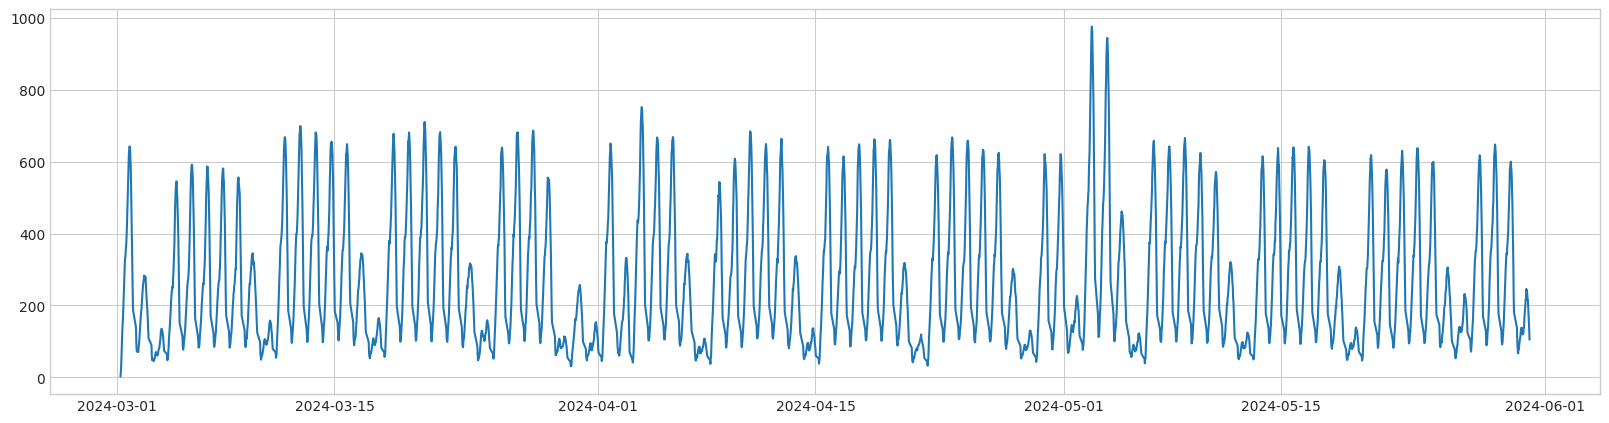

In [8]:
plt.figure(figsize=(20, 5))
plt.plot(sb["44783914"])
plt.show()

## Model

In [9]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cuda",  # use "cpu" for CPU inference and "mps" for Apple Silicon
    torch_dtype=torch.bfloat16,
)

## Data

In [10]:
# define X and Y
sbx = sb.query("index <= '2024-03-31 23:59:59'")
sbx.shape, sb.shape

((1238, 10), (3640, 10))

In [11]:
# define X and Y
sby = sb.query("index > '2024-03-31 23:59:59'")
sby.shape, sb.shape

((2402, 10), (3640, 10))

In [12]:
pred_len = abs(sbx.shape[0] - sb.shape[0])
pred_len

2402

In [13]:
sbx

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609
...,...,...,...,...,...,...,...,...,...,...
2024-03-31 21:30:00,8.525162,14.713684,466.679504,572.464783,40.153152,67.748451,140.110031,72.992035,16.047325,73.139664
2024-03-31 22:00:00,8.358495,11.963684,457.153748,544.450256,36.960098,61.056091,131.402695,69.995026,16.213991,70.889061
2024-03-31 22:30:00,8.032619,10.797018,435.691376,514.735413,36.256763,54.854801,123.299950,66.389008,13.727880,66.752312
2024-03-31 23:00:00,6.199285,10.463684,404.983246,480.096191,31.831995,49.224724,113.868469,61.778755,9.897774,63.470806


### Inference

In [14]:
forecast = pipeline.predict(context=torch.tensor(sbx["125960550"]),
                            prediction_length=pred_len,
                            limit_prediction_length=False,
                            num_samples=1)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


In [15]:
y_hat = forecast.view(-1)
y_pred =  y_hat.cpu().data.numpy()
y_pred.shape

(2402,)

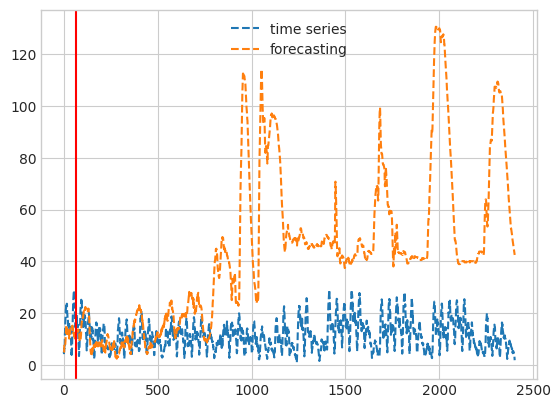

In [16]:
# only focasting
plt.plot(sby["125960550"].values, '--', label="time series")
plt.plot(y_pred, '--', label="forecasting")
plt.axvline(64, c='r')
plt.legend()
plt.show()

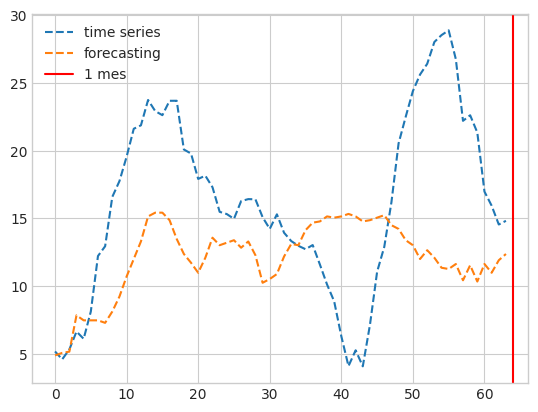

In [17]:
# only focasting - forecasting <= 64
plt.plot(sby["125960550"].values[:64], '--', label="time series")
plt.plot(y_pred[:64], '--', label="forecasting")
plt.axvline(64, c='r', label='1 mes')
#plt.axvline(64, c='k')
plt.legend()
plt.show()

In [18]:
len_fore = y_pred.shape[0]
len_fore

2402

In [19]:
limite_marco

NameError: name 'limite_marco' is not defined

In [ ]:
limite_marco = 31 * 40
limite_abril = limite_marco + (30 * 40)

# only focasting
plt.plot(np.arange(0, len(sb["125960550"])), sb["125960550"], '--', label="time series")
plt.plot(np.arange(limite_marco, limite_marco + len(y_pred)), y_pred, '--', label="forecasting")
#plt.plot(y_pred, '--', label="forecasting")

plt.axvline(limite_marco, c='r', label='fim maio')
plt.axvline(limite_abril, c='r', label='fim abril')
plt.legend()
plt.show()

### validation All

In [ ]:
nodes = sb.columns
nodes

In [ ]:
scores_error = {'node':[], 'mae': [], 'mse': [], 'r2': [], 'mape': []}

for node in nodes:
    forecast = pipeline.predict(context=torch.tensor(sbx[node]),
                            prediction_length=pred_len,
                            limit_prediction_length=False,
                            num_samples=1)
    
    y_hat = forecast.view(-1)
    y_pred =  y_hat.cpu().data.numpy()
    y_true = sby[node].values
    
    scores_error['node'].append(node)
    scores_error['mse'].append(mean_squared_error(y_true, y_pred))
    scores_error['mae'].append(mean_absolute_error(y_true, y_pred))
    scores_error['r2'].append(r2_score(y_true, y_pred))
    scores_error['mape'].append(mean_absolute_percentage_error(y_true, y_pred))
    

In [ ]:
df_results = pd.DataFrame(scores_error)
df_results

In [ ]:
df_results["model"] = "chronos-t5-base"

In [ ]:
df_results.columns

In [ ]:
df_results[['model', 'node', 'mae', 'mse', 'r2', 'mape']]

In [20]:
results = pd.read_parquet("CRHONOS-long-time.parquet")
results.head()

,node,mae,mse,r2,mape,model
0,125960550,33.465668,1.968526e+03,-65.973045,4.007134,SARIMA
1,230565994,17.709558,5.622633e+02,-1.314284,1.334176,SARIMA
2,258781031,566.579102,4.625947e+05,-1.010919,0.629109,SARIMA
3,43768720,3799.901367,1.890726e+07,-23.923290,4.449543,SARIMA
4,44072192,60.661293,5.614787e+03,-0.555314,0.715814,SARIMA


In [25]:
results[["mae", "mse", "r2", "mape"]]

,mae,mse,r2,mape
0,33.465668,1.968526e+03,-65.973045,4.007134
1,17.709558,5.622633e+02,-1.314284,1.334176
2,566.579102,4.625947e+05,-1.010919,0.629109
3,3799.901367,1.890726e+07,-23.923290,4.449543
4,60.661293,5.614787e+03,-0.555314,0.715814
5,130.586380,2.819596e+04,-0.637859,0.902294
6,219.045929,8.434198e+04,-1.336286,0.830648
7,168.755508,4.416297e+04,-1.927587,0.686985
8,69.585915,7.686245e+03,-2.394163,1.576177
9,88.771561,1.300129e+04,-2.712128,0.763199


In [26]:
results["mae"].mean()

515.5062280654907

In [30]:
results["mse"].mean()

1955538.673815918

In [31]:
results["r2"].mean()

-10.178487396240234

In [29]:
results["mape"].mean()

1.5895079135894776